# 02 - Customer Feature Engineering
Nội dung chính:
- Join 3 bảng: `sales`, `product`, `customer`.
- Tạo feature cơ bản và nâng cao theo `customer_id`.
- Gộp thông tin nhân khẩu học: giới tính, khu vực, hạng thành viên.
- Lưu output dùng cho bước modeling.

## 1) Setup


In [17]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)

def auto_find_project_root():
    current_dir = Path.cwd().resolve()
    for parent in [current_dir] + list(current_dir.parents):
        if (parent / 'src').exists() and (parent / 'data').exists():
            return parent

    # 2. KIỂM TRA MÔI TRƯỜNG GOOGLE COLAB: Nếu thấy Drive đã mount
    colab_drive = Path('/content/drive/MyDrive')
    if colab_drive.exists():
        # Quét tìm thư mục theo cơ chế hàng đợi (BFS) giới hạn 3 cấp độ sâu
        # Cách này giúp tìm thấy thư mục ngay cả khi nằm trong thư mục con khác mà không lo bị treo Drive
        queue = [colab_drive]
        for depth in range(3):
            next_queue = []
            for folder in queue:
                try:
                    # Nếu tìm thấy đúng thư mục tên 'Nhom-05-ML' hoặc thư mục có chứa 'src'
                    if folder.name == 'Nhom-05-ML' or (folder / 'src').exists():
                        return folder
                    # Nếu chưa thấy, thêm các thư mục con vào danh sách quét tiếp ở cấp sau
                    for sub in folder.iterdir():
                        if sub.is_dir() and not sub.name.startswith('.'):
                            next_queue.append(sub)
                except Exception:
                    continue
            queue = next_queue

    # Mặc định trả về thư mục hiện tại nếu không quét được
    return Path.cwd()

# Tự động xác định các đường dẫn dựa trên hàm trên
PROJECT_ROOT = auto_find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

# Thêm src vào hệ thống để import module
if SRC_DIR.exists():
    if str(SRC_DIR) not in sys.path:
        sys.path.append(str(SRC_DIR))
    print('Tự động nhận diện Project Root:', PROJECT_ROOT)
    print('Đã cấu hình sys.path thành công với:', SRC_DIR)
else:
    print('Không tìm thấy thư mục src. Hãy chắc chắn bạn đã mount Drive hoặc mở đúng thư mục dự án.')

print('Thư mục dữ liệu đã xử lý:', DATA_PROCESSED)

Tự động nhận diện Project Root: /content/drive/MyDrive/Nhom-05-ML
Đã cấu hình sys.path thành công với: /content/drive/MyDrive/Nhom-05-ML/src
Thư mục dữ liệu đã xử lý: /content/drive/MyDrive/Nhom-05-ML/data/processed


In [18]:
from build_customer_features import (
    load_clean_data,
    build_merged_transactions,
    build_customer_features,
    save_outputs,
)

sales, customer, product = load_clean_data(DATA_PROCESSED)

print('Kích thước sales   :', sales.shape)
print('Kích thước customer:', customer.shape)
print('Kích thước product :', product.shape)

Kích thước sales   : (3000, 10)
Kích thước customer: (500, 6)
Kích thước product : (30, 6)


## 2) Join 3 bảng thành bảng giao dịch gộp

In [19]:
merged = build_merged_transactions(sales, customer, product)
print('Kích thước merged:', merged.shape)
merged.head()

Kích thước merged: (3004, 15)


,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,line_amount,category,gender,customer_region,loyalty_tier
0,O966977,C00397,P0022,3,39.25,2025-07-06,Delivered,PayPal,Central,0.00,117.75,Cleaning,Female,North,Silver
1,O696648,C00236,P0023,5,18.92,2025-07-06,Delayed,Credit Card,North,0.00,94.60,Outdoors,Other,North,Gold
2,O202644,C00492,P0011,1,29.68,2025-07-06,Delivered,Bank Transfer,North,0.15,25.23,Kitchen,Male,Central,Gold
3,O501803,C00031,P0003,1,32.76,2025-07-06,Cancelled,Credit Card,Central,0.20,26.21,Cleaning,Female,Central,Gold
4,O322242,C00495,P0016,1,47.62,2025-07-06,Delayed,Credit Card,West,0.20,38.10,Cleaning,Male,Central,Gold


In [8]:
merge_quality = pd.DataFrame({
    'metric': [
        'unique customers in merged',
        'missing category',
        'missing gender',
        'missing customer_region',
        'missing loyalty_tier',
    ],
    'value': [
        merged['customer_id'].nunique(),
        int(merged['category'].isna().sum()),
        int(merged['gender'].isna().sum()),
        int(merged['customer_region'].isna().sum()),
        int(merged['loyalty_tier'].isna().sum()),
    ]
})
merge_quality


,metric,value
0,unique customers in merged,500
1,missing category,0
2,missing gender,0
3,missing customer_region,0
4,missing loyalty_tier,0


## 3) Tạo customer-level features

Các feature chính:
- `total_spent`, `avg_order_value`, `total_quantity`, `num_purchases`
- `days_since_first_purchase`, `days_since_last_purchase`
- `purchase_frequency`, `preferred_category`, `has_discount`
- `gender`, `customer_region`, `loyalty_tier`


In [9]:
customer_features = build_customer_features(merged, customer)
print('customer_features shape:', customer_features.shape)
customer_features.head()

customer_features shape: (500, 13)


,customer_id,total_spent,avg_order_value,num_purchases,total_quantity,has_discount,days_since_first_purchase,days_since_last_purchase,purchase_frequency,preferred_category,gender,customer_region,loyalty_tier
0,C00001,679.11,84.89,8,29,1,0,0,0.0,Outdoors,Male,Central,Silver
1,C00002,548.66,78.38,7,20,1,0,0,0.0,Outdoors,Female,Central,Gold
2,C00003,234.32,78.11,3,8,1,0,0,0.0,Kitchen,Male,Central,Gold
3,C00004,349.57,69.91,5,15,1,0,0,0.0,Cleaning,Female,Central,Gold
4,C00005,174.44,34.89,5,11,1,0,0,0.0,Outdoors,Male,West,Bronze


In [20]:
required_columns = [
    'customer_id',
    'total_spent',
    'avg_order_value',
    'total_quantity',
    'num_purchases',
    'days_since_first_purchase',
    'days_since_last_purchase',
    'purchase_frequency',
    'preferred_category',
    'has_discount',
    'gender',
    'customer_region',
    'loyalty_tier',
]

missing_cols = [c for c in required_columns if c not in customer_features.columns]
print('Các cột bắt buộc bị thiếu:', missing_cols)
print('Tổng số giá trị thiếu trong các cột bắt buộc:', int(customer_features[required_columns].isna().sum().sum()))

Các cột bắt buộc bị thiếu: []
Tổng số giá trị thiếu trong các cột bắt buộc: 0


## 4) Lưu output


In [21]:
save_outputs(merged, customer_features, DATA_PROCESSED)

merged_path = DATA_PROCESSED / 'merged_transactions.csv'
features_path = DATA_PROCESSED / 'customer_features.csv'

print('Đã lưu:', merged_path, '| số dòng =', sum(1 for _ in open(merged_path, 'r', encoding='utf-8')) - 1)
print('Đã lưu:', features_path, '| số dòng =', sum(1 for _ in open(features_path, 'r', encoding='utf-8')) - 1)

Đã lưu: /content/drive/MyDrive/Nhom-05-ML/data/processed/merged_transactions.csv | số dòng = 3004
Đã lưu: /content/drive/MyDrive/Nhom-05-ML/data/processed/customer_features.csv | số dòng = 500


## 5) Biểu đồ cho báo cáo

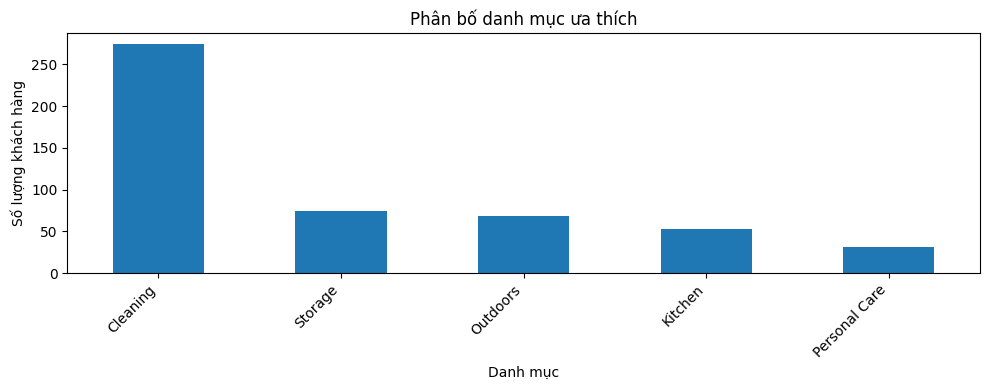

In [22]:
top_categories = customer_features['preferred_category'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
top_categories.plot(kind='bar')
plt.title('Phân bố danh mục ưa thích')
plt.xlabel('Danh mục')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

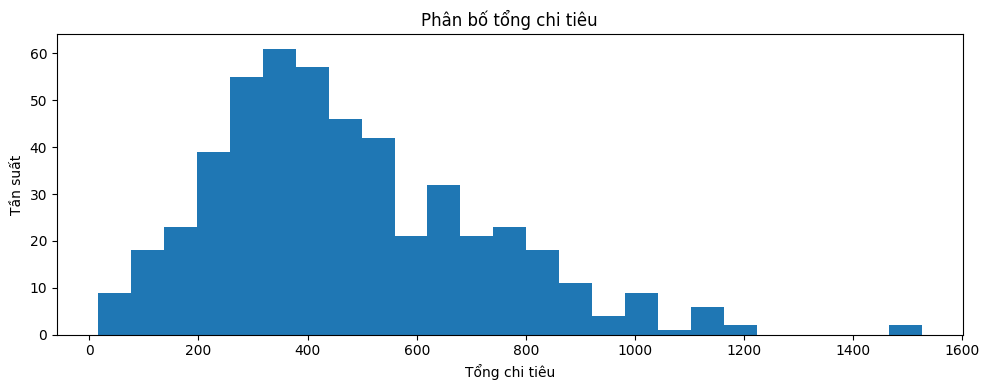

In [23]:
plt.figure(figsize=(10, 4))
customer_features['total_spent'].plot(kind='hist', bins=25)
plt.title('Phân bố tổng chi tiêu')
plt.xlabel('Tổng chi tiêu')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

## 6) Lưu ý

Trong bộ dữ liệu hiện tại, `order_date` chỉ có một mốc thời gian (`2025-07-06`) nên:
- `days_since_first_purchase` vì `days_since_last_purchase` bằng 0 cho mọi khách hàng.
- `purchase_frequency` cũng bằng 0 vì không có khoảng cách ngày giữa các lần mua.

Khi có dữ liệu đa thời điểm, 3 feature thời gian này sẽ phản ánh hành vi mua tốt hơn.
